In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import geopandas as gpd
import pickle

from shapely import Polygon
from cartoplanet.canvas import Canvas
from cartoplanet.projections import PLATE_CARREE, projections
from cartoplanet.boundaries import boundaries
from cartoplanet.layer import GridLayer, PointLayer, GeometryLayer

DATA = "/Users/mattjones/Brown Dropbox/Matthew Jones/Research Stuff/Jupyter notebooks/data/"
with open(DATA+"../moonmapping/data_dicts.pkl", "rb") as f:
  xr_dict, annt_dict = pickle.load(f)

In [2]:
# Grid data
th = xr_dict['th']

In [3]:
# Point data
with open(DATA+"regolith_thickness.pkl", "rb") as f:
  df_reg = pickle.load(f)

In [9]:
# Geometry data
with open(DATA+"USGSmare_nearside-laea.pkl", "rb") as f:
  mare_ns = pickle.load(f)
with open(DATA+"USGSmare_farside-laea.pkl", "rb") as f:
  mare_fs = pickle.load(f)


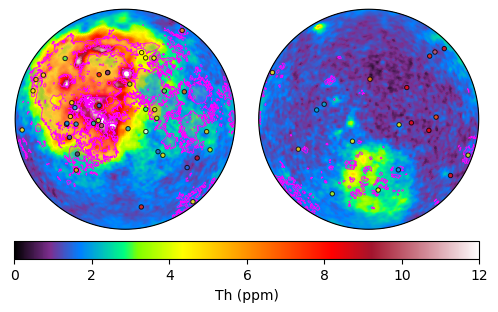

In [17]:
canvas = Canvas(
  nrows=1, ncols=2,
  with_cax=True,
  projections=[projections['LAEA_NS'], projections['LAEA_FS']],
  boundaries=boundaries['limb_circle']
)

grid_layer = GridLayer(
  name='thorium',
  data=th['th'].values,
  x=th['lon'].values,
  y=th['lat'].values,
  crs=PLATE_CARREE
)
point_layer = PointLayer(
  name='regolith',
  data=df_reg['rthick'].values,
  x=df_reg['lon'].values,
  y=df_reg['lat'].values,
  crs=PLATE_CARREE
)
geometry_layer_ns = GeometryLayer(
  name='mare_ns',
  data=mare_ns.to_crs(canvas[0].projection),
  crs=canvas[0].projection
  # data=mare_ns,
  # crs=mare_ns.crs
)
geometry_layer_fs = GeometryLayer(
  name='mare_fs',
  data=mare_fs.to_crs(canvas[1].projection),
  crs=canvas[1].projection
  # data=mare_fs,
  # crs=mare_fs.crs
)

cmap = th.attrs['cmap']
mare = [geometry_layer_ns, geometry_layer_fs]
for i, cv in enumerate(canvas):
  # Grid
  h = cv.draw(
    grid_layer, 
    cmap=cmap, 
    vmin=th.attrs['vmin'], 
    vmax=th.attrs['vmax']
  )
  # Geometry
  cv.draw(
    mare[i], 
    facecolor=[1, 0, 1, .2], 
    edgecolor=[1, 0, 1, 1], 
    lw=0.5
  )
  # Points
  cv.draw(
    point_layer, 
    c=point_layer.values,
    s=10, 
    ec=[0,0,0], 
    lw=.7, 
    alpha=0.8, 
    cmap=cmap, 
    vmin=2, 
    vmax=10
  )
plt.colorbar(h, cax=canvas.cax, orientation='horizontal', label=th.attrs['label'])
canvas.show()
# canvas.save("/Users/mattjones/Downloads/cartoplanet_demo.png")

In [8]:
geometry_layer_fs.crs

ProjError: Error creating Transformer from CRS.: (Internal Proj Error: proj_create_operations: Source and target ellipsoid do not belong to the same celestial body (Earth vs Moon). You may override this check by setting the PROJ_IGNORE_CELESTIAL_BODY environment variable to YES.)

<Projected CRS: +proj=laea +ellps=WGS84 +a=1737400.0 +b=1737400.0  ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Lambert Azimuthal Equal Area (Spherical)
Datum: unknown
- Ellipsoid: unknown
- Prime Meridian: Reference meridian

Error in callback <function _draw_all_if_interactive at 0x11eb0c700> (for post_execute):


ProjError: Error creating Transformer from CRS.: (Internal Proj Error: proj_create_operations: Source and target ellipsoid do not belong to the same celestial body (Earth vs Moon). You may override this check by setting the PROJ_IGNORE_CELESTIAL_BODY environment variable to YES.)

ProjError: Error creating Transformer from CRS.: (Internal Proj Error: proj_create_operations: Source and target ellipsoid do not belong to the same celestial body (Earth vs Moon). You may override this check by setting the PROJ_IGNORE_CELESTIAL_BODY environment variable to YES.)

<Figure size 500x300 with 1 Axes>